# 🏠 House Price Prediction Using Regression Models

## Introduction

The real estate market is one of the most important sectors in the economy, and accurately predicting house prices is crucial for buyers, sellers, and investors. House prices are influenced by many factors such as area, number of bedrooms, bathrooms, number of stories, parking space, and additional amenities like air conditioning, hot water heating, and furnishing status.

In this project, we aim to **predict house prices** using machine learning regression models. Accurate prediction of house prices can help:

- **Buyers** make informed decisions when purchasing a house.
- **Sellers** set competitive and fair prices for their properties.
- **Investors and analysts** understand which features have the most impact on housing prices.

## Problem Statement

House price prediction is challenging because it depends on multiple factors, both numerical (e.g., area, number of rooms) and categorical (e.g., presence of amenities, location features). Some of the common problems we aim to solve are:

1. **Complex relationships between features and prices:** Features may influence house prices in non-linear ways.  
2. **Handling categorical data:** Features like main road access, furnishing status, and air conditioning are categorical and must be processed properly for machine learning.  
3. **Choosing the best predictive model:** Different regression techniques may perform differently, so it is important to evaluate and select the most accurate and reliable model.  
4. **Generalization to unseen data:** The model should not just memorize the dataset (overfitting) but should predict prices accurately for new houses.  

## Objective

The objective of this project is to:

- Preprocess and analyze the house price dataset.
- Implement multiple regression models including **Linear Regression**, **Multiple Linear Regression**, **Polynomial Regression**, **KNN Regression**, and **Decision Tree Regression**.
- Evaluate and compare the models using metrics such as **MAE, MSE, and R² score**.
- Predict house prices for new data and select the **best performing model** based on evaluation results.
- Visualize model performance and feature importance to provide insights for real estate decision-making.

By the end of this project, we aim to identify which regression model provides the **most accurate and reliable house price predictions** while providing clear insights into the factors affecting house prices.


In [1]:
!git clone https://github.com/GurmesaAyele/Machine-Learning-Regression-Models-using-House-Price-Dataset.git


Cloning into 'Machine-Learning-Regression-Models-using-House-Price-Dataset'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 6.25 KiB | 6.25 MiB/s, done.


In [2]:
%cd Machine-Learning-Regression-Models-using-House-Price-Dataset


/content/Machine-Learning-Regression-Models-using-House-Price-Dataset


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [27]:
df = pd.read_csv("Housing Price.csv")
df.head()



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [26]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [13]:
df.columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [14]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [28]:
categorical_cols = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning',
    'prefarea', 'furnishingstatus'
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)



In [29]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
Linear Regression (Single Feature: area)

In [32]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train[['area']], y_train)

y_pred_lin = lin_reg.predict(X_test[['area']])


In [ ]:
Multiple Linear Regression

In [33]:
multi_reg = LinearRegression()
multi_reg.fit(X_train, y_train)

y_pred_multi = multi_reg.predict(X_test)


In [ ]:
Polynomial Regression (Degree = 2)

In [34]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred_poly = poly_reg.predict(X_test_poly)



In [ ]:
KNN Regression

In [35]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)



In [ ]:
Decision Tree Regression

In [37]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)



In [ ]:
Evaluation Function

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


In [ ]:
Evaluate All Models

In [39]:
results = {
    "Linear Regression": evaluate_model(y_test, y_pred_lin),
    "Multiple Linear Regression": evaluate_model(y_test, y_pred_multi),
    "Polynomial Regression": evaluate_model(y_test, y_pred_poly),
    "KNN Regression": evaluate_model(y_test, y_pred_knn),
    "Decision Tree Regression": evaluate_model(y_test, y_pred_dt),
}

results_df = pd.DataFrame(results).T
results_df



,MAE,MSE,R2
Linear Regression,1.474748e+06,3.675287e+12,0.272879
Multiple Linear Regression,9.700434e+05,1.754319e+12,0.652924
Polynomial Regression,1.034749e+06,1.901686e+12,0.623769
KNN Regression,9.995946e+05,1.953997e+12,0.613420
Decision Tree Regression,1.195266e+06,2.642803e+12,0.477146


In [ ]:
Choose the Best Model

In [40]:
best_model = results_df.sort_values(by="R2", ascending=False)
best_model


,MAE,MSE,R2
Multiple Linear Regression,9.700434e+05,1.754319e+12,0.652924
Polynomial Regression,1.034749e+06,1.901686e+12,0.623769
KNN Regression,9.995946e+05,1.953997e+12,0.613420
Decision Tree Regression,1.195266e+06,2.642803e+12,0.477146
Linear Regression,1.474748e+06,3.675287e+12,0.272879


In [ ]:
R² Score Comparison (BAR CHART)

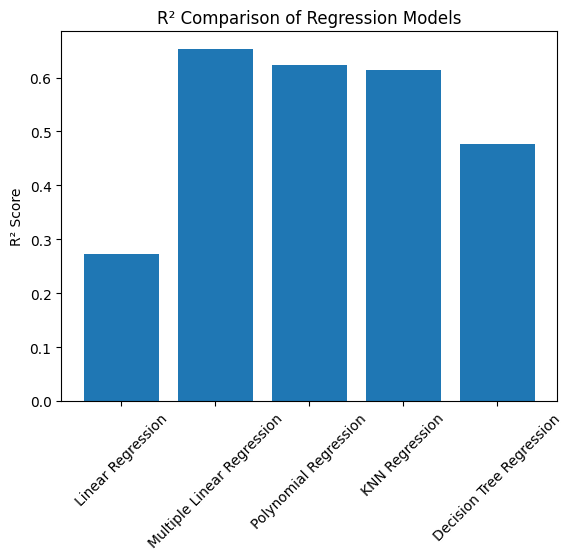

In [43]:
plt.figure()
plt.bar(results_df.index, results_df['R2'])
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("R² Comparison of Regression Models")
plt.show()


In [ ]:
MAE Comparison (BAR CHART)

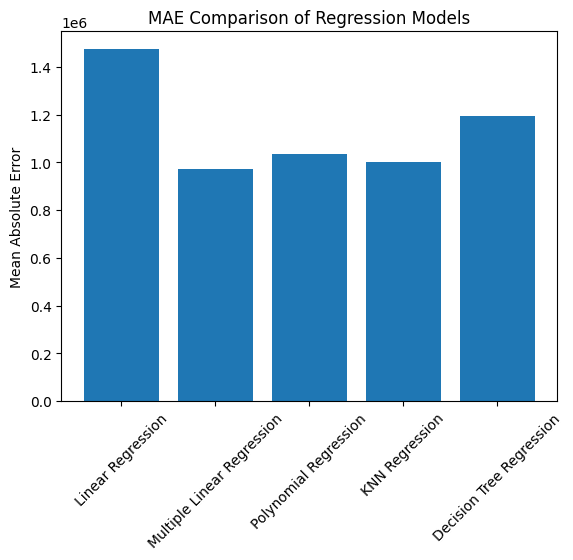

In [44]:
plt.figure()
plt.bar(results_df.index, results_df['MAE'])
plt.xticks(rotation=45)
plt.ylabel("Mean Absolute Error")
plt.title("MAE Comparison of Regression Models")
plt.show()


In [ ]:
Actual vs Predicted (BEST MODEL)

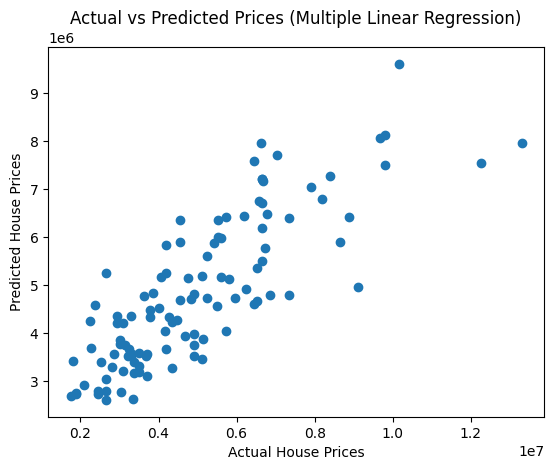

In [45]:
plt.figure()
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted Prices (Multiple Linear Regression)")
plt.show()


In [ ]:
Residual Plot (OPTIONAL BONUS)

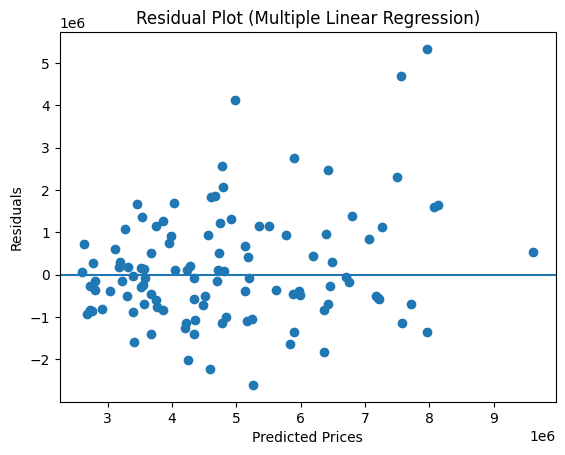

In [46]:
residuals = y_test - y_pred_multi

plt.figure()
plt.scatter(y_pred_multi, residuals)
plt.axhline(0)
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot (Multiple Linear Regression)")
plt.show()


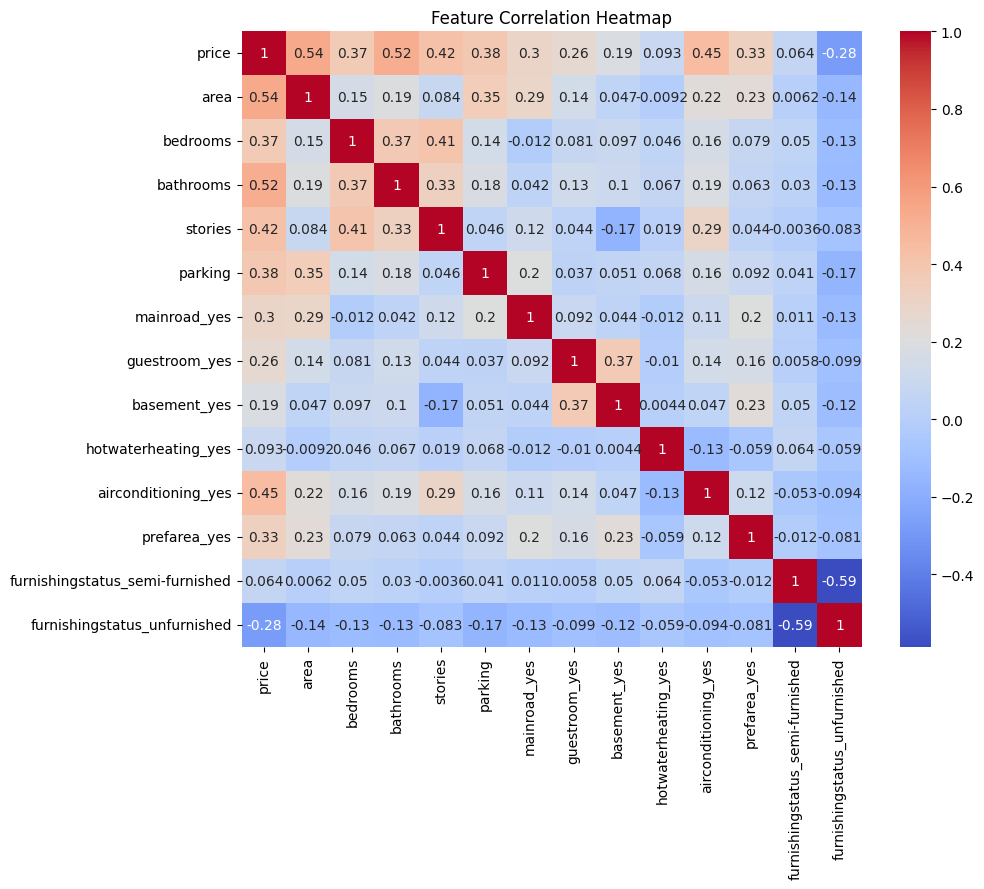

In [47]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


# 🏁 Conclusion and Model Comparison

In this study, several regression models were implemented to predict house prices using the given dataset, including **Linear Regression**, **Multiple Linear Regression**, **Polynomial Regression**, **KNN Regression**, and **Decision Tree Regression**. The models were evaluated using **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, and the **R² score**.

**Linear Regression** using only a single feature (**area**) showed the weakest performance among all models. It achieved a very low R² score (0.27), indicating that area alone is not sufficient to explain house price variations. This model ignores other important factors such as number of bedrooms, bathrooms, location-related features, and amenities, making it useful only as a baseline model.

**Multiple Linear Regression** produced the best overall performance. It achieved the lowest MAE and MSE and the highest R² score (0.65), meaning it explains approximately 65% of the variation in house prices. By considering all relevant features simultaneously, this model effectively captures the combined influence of property size, structure, and facilities. Its strong performance and simplicity make it the most reliable model for this dataset.

**Polynomial Regression** was used to capture non-linear relationships in the data. Although it performed better than simple linear regression, its accuracy was slightly lower than multiple linear regression. This suggests that while some non-linearity exists in the data, increasing model complexity through polynomial features did not significantly improve prediction accuracy and may have introduced mild overfitting.

**KNN Regression** showed moderate performance with an R² score of approximately 0.61. Its predictions depend heavily on the choice of neighbors and the distribution of the data. While KNN can model complex relationships, it is sensitive to noise and scaling, which can reduce its reliability for datasets with varied housing characteristics.

**Decision Tree Regression** performed worse than most other models, with a relatively low R² score of 0.48. Although decision trees can capture complex decision rules, this model likely overfitted the training data and did not generalize well to unseen data. Proper tuning, such as limiting tree depth, could improve its performance.

**Overall**, Multiple Linear Regression was selected as the best model due to its superior evaluation metrics, stability, and interpretability. The results demonstrate that, for this dataset, a well-preprocessed and properly applied linear model can outperform more complex regression techniques.
